# Lab 4 : Why Classical Machine Learning

###  Objectives 
* Understand the limitations of Classical Machine Learning methods.
* Learn how to convert text into numbers (vectors) for comparison.
* Compare Jaccard and Cosine Similarity techniques.
* Understand why Transformers are better than classical methods.


## Theory

Classical Machine Learning (ML) uses statistical and mathematical techniques to process and analyze data. When applied to text data, it converts words into numbers and uses mathematical formulas to find similarities between documents. This lab explores three key classical approaches and their limitations.

---

## 1. Jaccard Similarity

Jaccard Similarity measures the similarity between two documents by comparing their word sets. It is calculated by dividing the number of common words (intersection) by the total unique words (union). The value ranges from 0 to 1, where 1 means identical and 0 means completely different.

**Formula:**
$$JS = \frac{Intersection\ (\cap)}{Union\ (\cup)}$$

**Example:**

- Paper 1 : "Vision AI Vision" → { Vision, AI } ; Size = 2 *(unique words only)*
- Paper 2 : "NLP AI" → { NLP, AI } ; Size = 2

| | |
|---|---|
| Intersection (∩) | = 1 → {AI} |
| Union (∪) | = 3 → {Vision, AI, NLP} |

$$JS(Paper1, Paper2) = \frac{1}{3} = 0.33$$

**Limitations:**
- Word repeat is ignored
- Does not consider word frequency or meaning

---

## 2. Cosine Similarity

Cosine Similarity represents documents as vectors in multi-dimensional space and measures the angle between them. Each document is first converted into a word frequency vector. The similarity is then calculated using the dot product of the two vectors divided by the product of their magnitudes. It is more accurate than Jaccard as it considers word frequency, but still fails to understand the meaning of words.

**Formula:**
$$CS = \frac{A \cdot B}{|A| \times |B|}$$

Where:
$$A \cdot B = a_1a_2 + b_1b_2 + c_1c_2$$

**Example:**

Vocabulary = { Vision, AI, NLP }

| | Vision | AI | NLP |
|---|---|---|---|
| Paper 1 : "Vision AI Vision" | 2 | 1 | 0 |
| Paper 2 : "NLP AI" | 0 | 1 | 1 |

- Paper 1 = [2, 1, 0] → 3rd Dimensional
- Paper 2 = [0, 1, 1] → 3rd Dimensional

**Calculations:**

$$A \cdot B = (2 \times 0) + (1 \times 1) + (0 \times 1) = 1$$

$$|A| = \sqrt{2^2 + 1^2 + 0^2} = 2.236$$

$$|B| = \sqrt{0^2 + 1^2 + 1^2} = 1.414$$

$$|A| \times |B| = 3.162$$

$$CS = \frac{1}{3.162} = 0.316$$

**Errors / Limitations:**
- All vectors or words are treated equally
- We need something that has statistical weight

---

## 3. TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF improves upon simple word counting by assigning weights to words based on their importance. Words that appear frequently in one document but rarely in others get higher scores. This helps filter out common meaningless words and highlight important ones.

**Vocabulary** = { Transformer, For, NLP, CV, CNNs }

| Word | IDF Score |
|---|---|
| for | log(3/3) = 0 |
| Transformer | log(3/2) = 0.40 |
| NLP | log(3/1) = 1.1 |
| CV | log(3/2) = 0.40 |
| CNN | log(3/1) = 1.10 |

> Words like **"for"** get score 0 because they appear in all documents → not important
> Words like **"NLP"** and **"CNN"** get higher scores → more unique and important

---

## 4. KNN (K-Nearest Neighbors)

KNN is a simple classification algorithm that works by finding the K most similar documents to a new input document using similarity measures like Cosine Similarity. It then assigns the label based on the majority class among those K neighbors. While simple and effective for small datasets, it becomes slow and inaccurate for large and complex text data.

---

## 5. Why Transformers Are Better

To overcome the limitations of classical ML, modern Transformer-based models were introduced:

- ① Transformer for NLP
- ② Transformer for CV
- ③ CNNs for CV

Transformers use a mechanism called **self-attention** which allows them to understand the context of each word in relation to all other words in a sentence. This makes them far superior for tasks like document classification, sentiment analysis, and image recognition compared to classical ML methods.

---



## 

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors


paper_titles = [
    # Computer Vision Papers (1-10)
    ("ResNet-3D: Residual Grids for Spatial Volumetric Analysis", "CV", "CNNs", "Dr_Y_LeCun"),
    ("ViT-Scale: Scaling Vision Transformers for Dense Prediction", "CV", "Transformers", "Dr_A_Vaswani"),
    ("SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision", "CV", "CL", "Dr_G_Hinton"),
    ("Masked Autoencoders Are Scalable Vision Visualizers", "CV", "Transformers", "Dr_Y_LeCun"),
    ("NeRF-Graph: Neural Radiance Fields on Graph Topologies", "CV", "GNNs", "Dr_J_Leskovec"),
    ("Real-Time Semantic Segmentation via Dilated Spatial Kernels", "CV", "CNNs", "Dr_Y_LeCun"),
    ("Cross-Modal Vector Alignment in Generative Vision Spaces", "CV", "CL", "Dr_G_Hinton"),
    ("Attention-Driven Object Detection in High-Resolution Imagery", "CV", "Transformers", "Dr_A_Vaswani"),
    ("Unsupervised Visual Representation via Contrastive Residuals", "CV", "CL", "Dr_G_Hinton"),
    ("Geometry-Aware Convolutions for 3D Point Cloud Processing", "CV", "CNNs", "Dr_J_Leskovec"),
    
    # NLP Papers (11-20)
    ("BERT-Large: Pre-training of Deep Bidirectional Transformers", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("GPT-Next: Autoregressive Language Modeling at Scale", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Contrastive Sentence Embeddings via Semantic Invariance", "NLP", "CL", "Dr_Y_Bengio"),
    ("Long-Short Sequence Parsing via Linear Attention Windows", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Text-Graph Recurrent Transformers for Structured Document Analysis", "NLP", "GNNs", "Dr_J_Leskovec"),
    ("Exploring the Limits of Self-Supervised Machine Translation", "NLP", "CL", "Dr_Y_Bengio"),
    ("Dependency-Parsing Convolutions for Low-Resource Languages", "NLP", "CNNs", "Dr_Y_LeCun"),
    ("Token-Free Language Representations via Character-Level Processing", "NLP", "Transformers", "Dr_Y_Bengio"),
    ("Retrieval-Augmented Transformers for Dynamic Knowledge Graphs", "NLP", "Transformers", "Dr_J_Leskovec"),
    ("Evaluating Prompt Calibration Metrics in LLM Quantization", "NLP", "Transformers", "Dr_Y_Bengio"),

    # Graph AI Papers (21-30)
    ("GCN-V2: Scalable Graph Convolutional Networks via Node Sampling", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Graph Attention Networks with Multi-Head Structural Alignment", "Graph_AI", "Transformers", "Dr_A_Vaswani"),
    ("Self-Supervised Graph Contrastive Learning via Subgraph Masking", "Graph_AI", "CL", "Dr_Y_Bengio"),
    ("Message-Passing Frameworks for Heterogeneous Molecular Topologies", "Graph_AI", "GNNs", "Dr_G_Hinton"),
    ("Graph Convolutions Meet Vision Transformers: A Unified Review", "Graph_AI", "Transformers", "Dr_Y_LeCun"),
    ("Temporal Graph Networks for Dynamic Relational Interaction Stream", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Inductive Representation Learning on Large-Scale Social Webs", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Contrastive Node Clustering via Graph Diffusion Wavelets", "Graph_AI", "CL", "Dr_G_Hinton"),
    ("Deep Generative Models for Graph Structure Deconvolution", "Graph_AI", "CNNs", "Dr_Y_LeCun"),
    ("Scalable Graph Neural Architecture Search via Gradient Descent", "Graph_AI", "GNNs", "Dr_Y_Bengio")
]

# Convert the raw nested sequence into a structured Pandas DataFrame
columns = ["Title", "Domain_Code", "Methodology_Code", "Primary_Author"]
df = pd.DataFrame(paper_titles, columns=columns)
df.insert(0, 'Paper_ID', range(1, len(df) + 1))

# Optionally save to disk to inspect structural data
df.to_csv('research_papers_network.csv', index=False)


# Combine descriptive features and text metadata fields into a singular text profile string
df['Features_Corpus'] = df['Title'] + " " + df['Domain_Code'] + " " + df['Methodology_Code'] + " " + df['Primary_Author']

# Lowercase everything to ensure string consistency and eliminate casing bias
df['Features_Corpus'] = df['Features_Corpus'].str.lower()


vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b\w+\b')

tfidf_matrix = vectorizer.fit_transform(df['Features_Corpus'])


knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

target_title = "Unsupervised Visual Representation via Contrastive Residuals"
query_idx = df[df['Title'] == target_title].index[0]

# Query the KNN tree to get spatial coordinate arrays for closest nodes
distances, indices = knn_model.kneighbors(tfidf_matrix[query_idx])

# Display machine learning recommendations
print(f"Target Input Paper: '{df.iloc[query_idx]['Title']}'")
print("=" * 95)

# Loop starting from index 1 (skipping 0 because index 0 is always the target paper itself)
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    cosine_distance = distances[0][rank]
    
    # Mathematical transformation: Similarity = 1 - Distance
    similarity_score = 1 - cosine_distance
    
    print(f"ML Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]")


Target Input Paper: 'Unsupervised Visual Representation via Contrastive Residuals'
ML Recommendation #01: SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision           [Score: 0.2873]
ML Recommendation #02: Contrastive Node Clustering via Graph Diffusion Wavelets               [Score: 0.2475]
ML Recommendation #03: Cross-Modal Vector Alignment in Generative Vision Spaces               [Score: 0.1885]
ML Recommendation #04: Contrastive Sentence Embeddings via Semantic Invariance                [Score: 0.1640]
ML Recommendation #05: Self-Supervised Graph Contrastive Learning via Subgraph Masking        [Score: 0.1553]


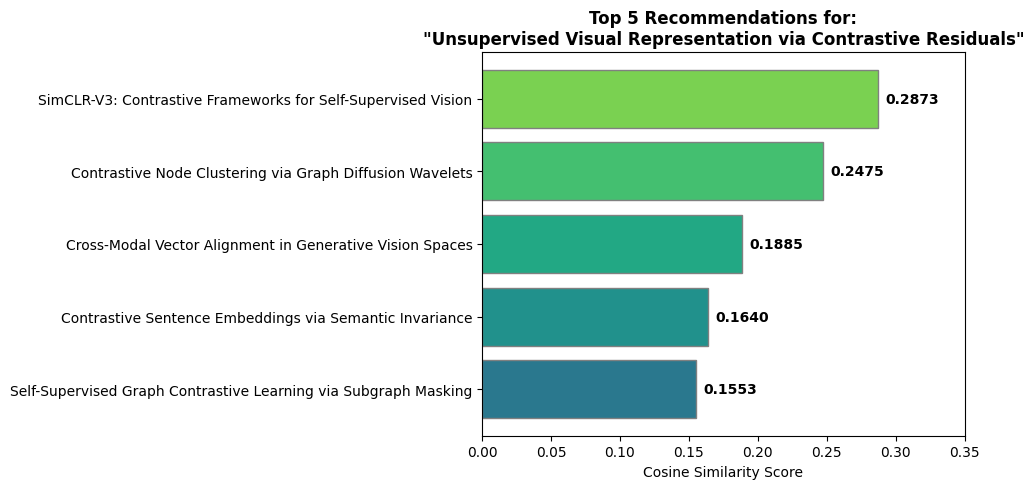

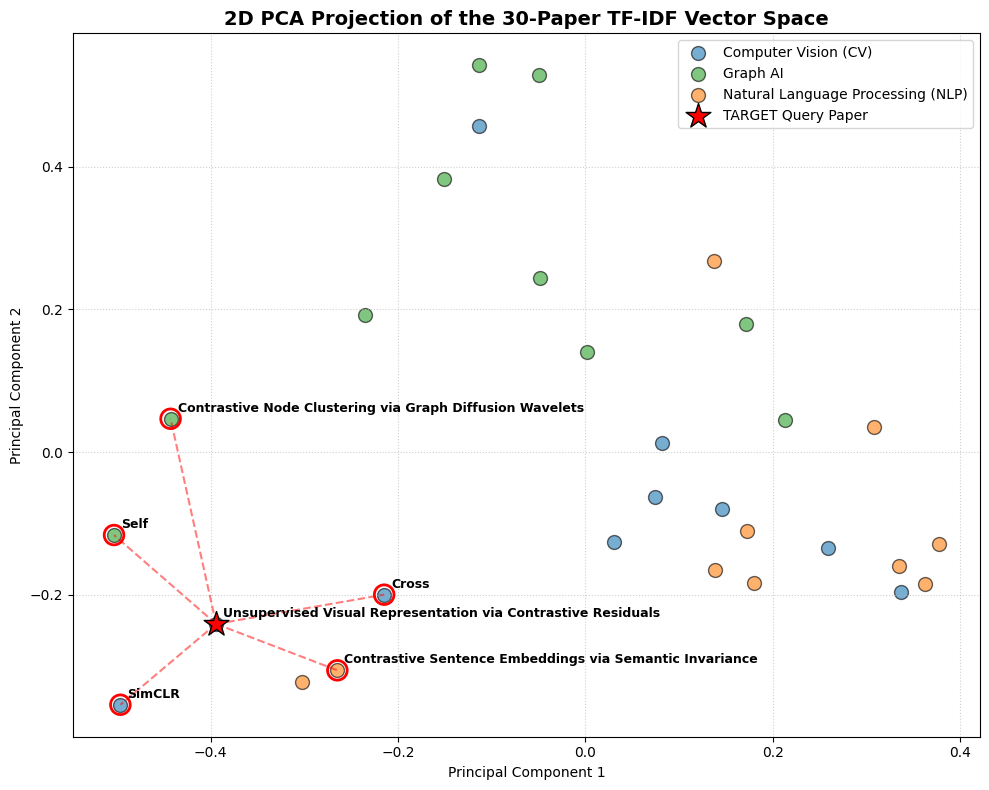

Visualizations successfully compiled and saved to disk.


In [3]:
## next tab

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==============================================================================
# VISUALIZATION MODULE 1: HORIZONTAL BAR CHART OF TOP SIMILARITIES
# ==============================================================================
rec_titles = []
rec_scores = []
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    sim_score = 1 - distances[0][rank]
    rec_titles.append(df.iloc[match_idx]['Title'])
    rec_scores.append(sim_score)

# Sort recommendations to guarantee sorted descending presentation
rec_data = sorted(zip(rec_titles, rec_scores), key=lambda x: x[1])
sorted_titles, sorted_scores = zip(*rec_data)

# Create Plot canvas using standard subplots to avoid truncation
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(sorted_scores)))
bars = ax.barh(sorted_titles, sorted_scores, color=colors, edgecolor='grey')

ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 5 Recommendations for:\n"{target_title}"', fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.35)

# Append raw score values cleanly onto the tips of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()


# ==============================================================================
# VISUALIZATION MODULE 2: 2D GEOMETRIC PCA PROJECTION 
# ==============================================================================
# Compress sparse matrix coordinates to a 2D dense layout plane
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df['X'], df['Y'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

# Distribute colors cleanly mapping across academic domain codes
domain_colors = {'CV': '#1f77b4', 'NLP': '#ff7f0e', 'Graph_AI': '#2ca02c'}
domain_labels = {'CV': 'Computer Vision (CV)', 'NLP': 'Natural Language Processing (NLP)', 'Graph_AI': 'Graph AI'}

for domain, group in df.groupby('Domain_Code'):
    ax.scatter(group['X'], group['Y'], label=domain_labels[domain], 
               color=domain_colors[domain], s=100, alpha=0.6, edgecolors='black')

# Anchor and highlight target paper index
target_x, target_y = df.iloc[query_idx]['X'], df.iloc[query_idx]['Y']
ax.scatter(target_x, target_y, color='red', marker='*', s=350, 
           label='TARGET Query Paper', edgecolors='black', zorder=5)

# Draw spatial connection lines to matching neighbors
neighbor_indices = indices[0][1:]
for idx in neighbor_indices:
    nx, ny = df.iloc[idx]['X'], df.iloc[idx]['Y']
    ax.scatter(nx, ny, facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=4)
    ax.plot([target_x, nx], [target_y, ny], color='red', linestyle='--', alpha=0.5, zorder=3)

# Overlay short acronym annotations onto the vector nodes
for i, row in df.iterrows():
    if i == query_idx or i in neighbor_indices:
        short_name = row['Title'].split(':')[0].split('-')[0]
        ax.annotate(short_name, (row['X'], row['Y']), textcoords="offset points", 
                    xytext=(5,5), ha='left', fontsize=9, weight='bold')

ax.set_title('2D PCA Projection of the 30-Paper TF-IDF Vector Space', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# plt.savefig('vector_space_projection.png', dpi=300)
plt.show()
plt.close()

print("Visualizations successfully compiled and saved to disk.")

## Discussion
In this lab, we studied classical machine learning techniques for text similarity and document retrieval, including Jaccard Similarity, Cosine Similarity, TF-IDF, and KNN. Jaccard similarity measures simple word overlap but ignores frequency and meaning, while cosine similarity improves this by using vector representations to consider word frequency. TF-IDF further enhances performance by assigning higher weights to important and unique words while reducing the impact of common words. KNN then uses these similarity measures to find the most relevant documents for a given query, making it useful for small-scale recommendation tasks. However, all these methods are limited in understanding the actual context or semantic meaning of text, which is why modern Transformer-based models are preferred for more advanced natural language processing tasks.

## Conclusion

Classical ML methods like Jaccard Similarity, Cosine Similarity, and TF-IDF are simple and easy to understand but fail to capture the deeper semantic meaning of words. KNN works well for small datasets but struggles with large and complex text. This is why modern Transformer-based models are preferred for real-world NLP and Computer Vision tasks.